<a href="https://colab.research.google.com/github/lizbethQCC/2024/blob/main/Analisis_Electoral_70223992.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio y Visualización de Resultados Electorales de la ONPE 2026
## Primera Vuelta Presidencial · Perú · 12 de abril de 2026

**Fuente de datos:** Oficina Nacional de Procesos Electorales (ONPE)  
**Plataforma oficial:** https://resultadoelectoral.onpe.gob.pe  
**Avance del cómputo:** 98.767 % de actas contabilizadas (al 08/05/2026 01:15 a.m.)  
- Actas contabilizadas: 91,622  
- Actas para envío al JEE: 1,144  
- Actas pendientes: 0  

**Herramientas:** Python 3 · NumPy · Pandas · Matplotlib   
**Entorno recomendado:** Google Colab

**Autor:** Lisbet Quispe C.   
**DNI:** 70223992


In [2]:
# ─────────────────────────────────────────────────────────────
# CELDA 1 — Importación de librerías
# ─────────────────────────────────────────────────────────────
import numpy as np # Importar la librería NumPy para operaciones numéricas y array
import pandas as pd # Importar el módulo pyplot de Matplotlib para crear gráficos
import matplotlib.pyplot as plt # Importar el módulo pyplot de Matplotlib para crear gráficos
import matplotlib.ticker as mticker # Importar el submódulo ticker para personalizar los ticks de los ejes
from scipy.stats import gaussian_kde # # Importar la función gaussian_kde de SciPy para estimación de densidad por kernel
# Configuración global de estilo
plt.rcParams.update({
    "figure.facecolor": "white",  # Fondo de la figura en blanco
    "axes.facecolor":   "#f8f9fa", # Fondo de los ejes gris muy claro
    "axes.grid":        True, # Activar cuadrícula en los gráficos
    "grid.color":       "#dee2e6", # Color de la cuadrícula gris suave
    "grid.linestyle":   "--", # Estilo de línea punteada para la cuadrícula
    "grid.alpha":       0.5,  # Transparencia de la cuadrícula al 50%
    "font.family":      "DejaVu Sans",  # Fuente tipográfica utilizada en los gráficos
})

print("✅ Librerías importadas correctamente.") # Imprimir mensaje de confirmación de importación de librerías
print(f"   NumPy   : {np.__version__}") # Imprimir la versión de NumPy instalada
print(f"   Pandas  : {pd.__version__}") # Imprimir la versión de Pandas instalada
print(f"   Matplotlib cargado")


✅ Librerías importadas correctamente.
   NumPy   : 2.0.2
   Pandas  : 2.2.2
   Matplotlib cargado


---
## 1. Construcción del Dataset Electoral

Los datos corresponden a los **resultados oficiales de la ONPE al 98.767 % de actas contabilizadas**,  
publicados el 08 de mayo de 2026. Se incluyen los 10 candidatos con mayor votación.  
Los porcentajes se calculan sobre el total de **votos válidos** emitidos a nivel nacional.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELDA 2 — Construcción del dataset electoral
# Fuente: ONPE — Elecciones Generales 2026, primera vuelta
# Avance: 98.767% de actas contabilizadas (08/05/2026)
# ─────────────────────────────────────────────────────────────

# Arrays NumPy para cómputo estadístico

# Crear array con nombres de candidatos presidenciales (incluye salto de línea con \n)
candidatos = np.array([
    "Keiko Fujimori\n(Fuerza Popular)",           # Candidata 1
    "Roberto Sánchez\n(Juntos por el Perú)",      # Candidato 2
    "Rafael López Aliaga\n(Renovación Popular)",  # Candidato 3
    "Jorge Nieto Montesinos\n(Partido del Buen Gobierno)",  # Candidato 4
    "Ricardo Belmont\n(Partido Cívico Obras)",    # Candidato 5
    "Carlos Álvarez Loayza\n(País para Todos)",   # Candidato 6
    "Pablo López Chau\n(Ahora Nación - AN)",      # Candidato 7
    "María Pérez Tello\n(Primero la Gente)",      # Candidata 8
    "Alfonso Espa\n(Partido Sicreo)",             # Candidato 9
    "Otros candidatos",                           # Agrupación del resto
])

# Votos válidos (%) — fuente: ONPE al 98.767% de actas
votos = np.array([
    17.051,
    12.004,
    11.921,
    11.065,
    10.167,
     7.886,
     7.346,
     3.431,
     3.376,
    15.753,
])

# Votos absolutos aproximados (fuente: Infobae / ONPE)
votos_abs = np.array([
    2_840_294,  # Keiko Fujimori (referencial — cifra más alta)
    1_890_544,  # Roberto Sánchez
    1_877_454,  # Rafael López Aliaga
    1_742_583,  # Jorge Nieto Montesinos
    1_601_258,  # Ricardo Belmont
    1_241_945,  # Carlos Álvarez Loayza
    1_156_943,  # Pablo López Chau
      540_361,  # María Pérez Tello
      531_691,  # Alfonso Espa
          0,    # "Otros" — no se desagrega (valor 0)
], dtype=float)

# DataFrame Pandas para análisis tabular
df = pd.DataFrame({
    "candidato": candidatos,           # Asignar columna de nombres
    "porcentaje_votos": votos,         # Asignar columna de porcentajes
    "votos_absolutos": votos_abs,      # Asignar columna de votos absolutos
})

# Ordenar por porcentaje de votos de mayor a menor
df = df.sort_values("porcentaje_votos", ascending=False).reset_index(drop=True)

# Crear columna "rango" con posición (1,2,3...)
df["rango"] = df.index + 1

# Configurar opciones de visualización de Pandas
pd.set_option("display.max_colwidth", 50)   # Máximo ancho de columna: 50 caracteres
pd.set_option("display.float_format", "{:.3f}".format)  # Mostrar floats con 3 decimales

# Imprimir encabezado
print("=" * 70)
print("RESULTADOS ONPE — PRIMERA VUELTA PRESIDENCIAL PERÚ 2026")
print(f"Avance: 98.767% de actas contabilizadas | Fecha: 08/05/2026")
print("=" * 70)

# Imprimir tabla con rango, candidato, porcentaje y votos absolutos (sin índice)
print(df[["rango","candidato","porcentaje_votos","votos_absolutos"]].to_string(index=False))


RESULTADOS ONPE — PRIMERA VUELTA PRESIDENCIAL PERÚ 2026
Avance: 98.767% de actas contabilizadas | Fecha: 08/05/2026
 rango                                           candidato  porcentaje_votos  votos_absolutos
     1                    Keiko Fujimori\n(Fuerza Popular)            17.051      2840294.000
     2                                    Otros candidatos            15.753            0.000
     3               Roberto Sánchez\n(Juntos por el Perú)            12.004      1890544.000
     4           Rafael López Aliaga\n(Renovación Popular)            11.921      1877454.000
     5 Jorge Nieto Montesinos\n(Partido del Buen Gobierno)            11.065      1742583.000
     6             Ricardo Belmont\n(Partido Cívico Obras)            10.167      1601258.000
     7            Carlos Álvarez Loayza\n(País para Todos)             7.886      1241945.000
     8               Pablo López Chau\n(Ahora Nación - AN)             7.346      1156943.000
     9               María Pérez Tello

---
## 2. Análisis Estadístico Descriptivo con NumPy

Se calculan las métricas clásicas de estadística descriptiva sobre el vector de porcentajes  
de los **9 candidatos individuales** (excluyendo el agregado "Otros candidatos") para medir  
dispersión, concentración y heterogeneidad del voto.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELDA 3 — Estadística descriptiva con NumPy
# Se excluye "Otros candidatos" (índice -1) del análisis
# ─────────────────────────────────────────────────────────────
# Seleccionar solo los 9 candidatos individuales (excluir "Otros candidatos")
votos_ind = votos[:-1]   # 9 candidatos individuales

# Calcular estadísticas básicas
media      = np.mean(votos_ind)                        # Promedio aritmético
mediana    = np.median(votos_ind)                      # Valor central
desv_std   = np.std(votos_ind, ddof=0)                 # Desviación estándar poblacional (ddof=0)
varianza   = np.var(votos_ind,  ddof=0)                # Varianza poblacional
rango      = np.ptp(votos_ind)                         # Rango = valor máximo - valor mínimo
cv         = (desv_std / media) * 100                  # Coeficiente de variación (porcentaje)
q1, q3     = np.percentile(votos_ind, [25, 75])        # Cuartil 1 (25%) y cuartil 3 (75%)
iqr        = q3 - q1                                   # Rango intercuartil
asimetria  = (3 * (media - mediana)) / desv_std         # Coeficiente de asimetría de Pearson

# Línea separadora (42 guiones)
sep = "─" * 42

# Imprimir bloque de métricas estadísticas
print(sep)
print(f"  MÉTRICAS ESTADÍSTICAS — ONPE 2026")
print(f"  (9 candidatos individuales, votos válidos %)")
print(sep)
print(f"  Media aritmética      : {media:>8.3f} %")
print(f"  Mediana               : {mediana:>8.3f} %")
print(f"  Desviación estándar   : {desv_std:>8.3f} pp")      # pp = puntos porcentuales
print(f"  Varianza              : {varianza:>8.3f}")
print(f"  Rango (max - min)     : {rango:>8.3f} pp")
print(f"  Q1 (percentil 25)     : {q1:>8.3f} %")
print(f"  Q3 (percentil 75)     : {q3:>8.3f} %")
print(f"  IQR (Q3 - Q1)         : {iqr:>8.3f} pp")
print(f"  Coef. de variación    : {cv:>8.1f} %")
print(f"  Coef. asimetría Pearson: {asimetria:>7.3f}")
print(sep)

# Encontrar candidato más votado y menos votado
idx_max = np.argmax(votos_ind)                         # Índice del valor máximo
idx_min = np.argmin(votos_ind)                         # Índice del valor mínimo

# Imprimir candidato con mayor votación (reemplazar \n por espacio)
print(f"\n  ▲ Mayor votación  : {candidatos[idx_max].replace(chr(10),' ')} ({votos_ind[idx_max]:.3f}%)")

# Imprimir candidato con menor votación
print(f"  ▼ Menor votación  : {candidatos[idx_min].replace(chr(10),' ')} ({votos_ind[idx_min]:.3f}%)")
print(sep)

──────────────────────────────────────────
  MÉTRICAS ESTADÍSTICAS — ONPE 2026
  (9 candidatos individuales, votos válidos %)
──────────────────────────────────────────
  Media aritmética      :    9.361 %
  Mediana               :   10.167 %
  Desviación estándar   :    4.129 pp
  Varianza              :   17.050
  Rango (max - min)     :   13.675 pp
  Q1 (percentil 25)     :    7.346 %
  Q3 (percentil 75)     :   11.921 %
  IQR (Q3 - Q1)         :    4.575 pp
  Coef. de variación    :     44.1 %
  Coef. asimetría Pearson:  -0.586
──────────────────────────────────────────

  ▲ Mayor votación  : Keiko Fujimori (Fuerza Popular) (17.051%)
  ▼ Menor votación  : Alfonso Espa (Partido Sicreo) (3.376%)
──────────────────────────────────────────


---
## 3. Visualizaciones

### 3.1 Gráfico de Barras Horizontales — Resultados por Candidato


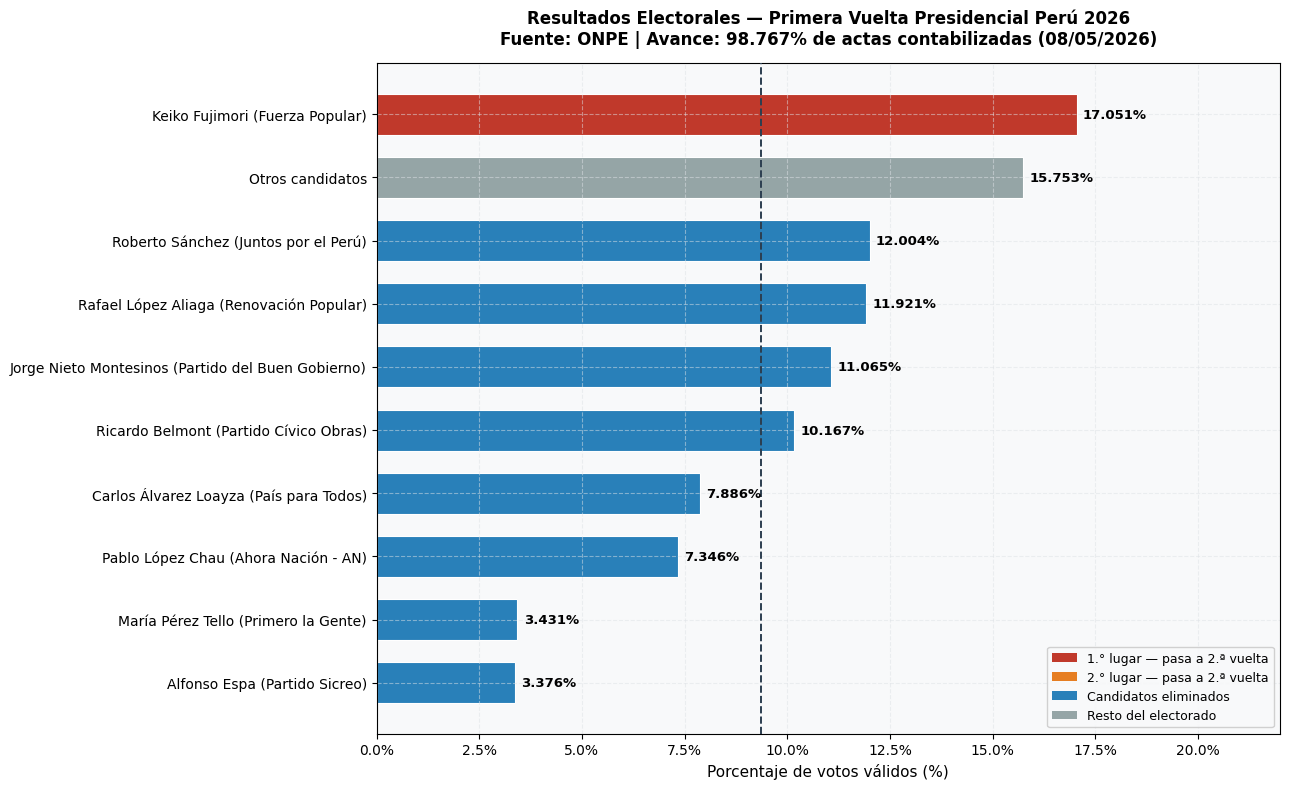

✅ Gráfico guardado: onpe2026_barras.png


In [5]:
# ─────────────────────────────────────────────────────────────
# CELDA 4 — Gráfico de barras horizontales
# ─────────────────────────────────────────────────────────────
# Diccionario de colores para cada categoría de candidato
COLORES = {
    "ganador":    "#c0392b",   # rojo — primer lugar
    "2do_vuelta": "#e67e22",   # naranja — segundo lugar (segunda vuelta)
    "resto":      "#2980b9",   # azul — demás candidatos
    "otros":      "#95a5a6",   # gris — agregado "Otros"
}

# Función que asigna color según posición y nombre del candidato
def asignar_color(i, nombre):
    if "Otros" in nombre:              # Si el nombre contiene "Otros"
        return COLORES["otros"]        # Usar color gris
    if i == 0:                         # Primer lugar
        return COLORES["ganador"]      # Usar rojo
    if i == 1:                         # Segundo lugar
        return COLORES["2do_vuelta"]   # Usar naranja
    return COLORES["resto"]            # Resto de candidatos usan azul

# Generar lista de colores para cada barra (usando la función asignar_color)
colores_barras = [asignar_color(i, c) for i, c in enumerate(df["candidato"])]

# Crear etiquetas reemplazando saltos de línea por espacios
etiquetas      = [c.replace("\n", " ") for c in df["candidato"]]

# Crear figura y ejes (tamaño 13x8 pulgadas)
fig, ax = plt.subplots(figsize=(13, 8))

# Crear gráfico de barras horizontales
bars = ax.barh(
    etiquetas,                         # Etiquetas del eje Y
    df["porcentaje_votos"],            # Valores del eje X (porcentajes)
    color=colores_barras,              # Colores asignados
    edgecolor="white",                 # Borde blanco para cada barra
    linewidth=0.8,                     # Grosor del borde
    height=0.65,                       # Altura de las barras
)

# Calcular media excluyendo "Otros" (solo 9 candidatos)
votos_ind = votos[:-1]                 # Excluir último elemento ("Otros")
media_ind = np.mean(votos_ind)         # Media aritmética

# Línea vertical que representa la media
ax.axvline(
    x=media_ind,                       # Posición X de la línea
    color="#2c3e50", linestyle="--", linewidth=1.4,  # Estilo: gris oscuro, punteado
    label=f"Media (9 candidatos): {media_ind:.2f}%",  # Etiqueta para leyenda
    zorder=3,                          # Capa superior (por encima de las barras)
)

# Agregar etiquetas de valor al final de cada barra
for bar, val in zip(bars, df["porcentaje_votos"]):
    ax.text(
        val + 0.15,                    # Posición X (valor + pequeño margen)
        bar.get_y() + bar.get_height() / 2,  # Centrado vertical
        f"{val:.3f}%",                 # Texto a mostrar
        va="center", ha="left",        # Alineación: centro vertical, izquierda horizontal
        fontsize=9.5, fontweight="bold",  # Tamaño y negrita
    )

# Invertir eje Y (el primer lugar arriba)
ax.invert_yaxis()

# Etiqueta del eje X
ax.set_xlabel("Porcentaje de votos válidos (%)", fontsize=11)

# Título del gráfico (con salto de línea)
ax.set_title(
    "Resultados Electorales — Primera Vuelta Presidencial Perú 2026\n"
    "Fuente: ONPE | Avance: 98.767% de actas contabilizadas (08/05/2026)",
    fontsize=12, fontweight="bold", pad=14,
)

# Formato del eje X como porcentaje con 1 decimal
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

# Límite máximo del eje X (para dejar espacio a las etiquetas)
ax.set_xlim(0, 22)

# Leyenda para la línea de la media
ax.legend(fontsize=10, loc="lower right")

# Importar Patch para crear la leyenda de colores
from matplotlib.patches import Patch

# Definir elementos de la leyenda de colores
leyenda = [
    Patch(facecolor=COLORES["ganador"],    label="1.° lugar — pasa a 2.ª vuelta"),
    Patch(facecolor=COLORES["2do_vuelta"], label="2.° lugar — pasa a 2.ª vuelta"),
    Patch(facecolor=COLORES["resto"],      label="Candidatos eliminados"),
    Patch(facecolor=COLORES["otros"],      label="Resto del electorado"),
]

# Agregar leyenda de colores al gráfico
ax.legend(handles=leyenda, loc="lower right", fontsize=9, framealpha=0.9)

# Ajustar espaciado automático para evitar solapamientos
plt.tight_layout()

# Guardar el gráfico como archivo PNG (150 dpi)
plt.savefig("onpe2026_barras.png", dpi=150, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

# Mensaje de confirmación de guardado
print("✅ Gráfico guardado: onpe2026_barras.png")

### 3.2 Gráfico Circular — Distribución Relativa del Voto

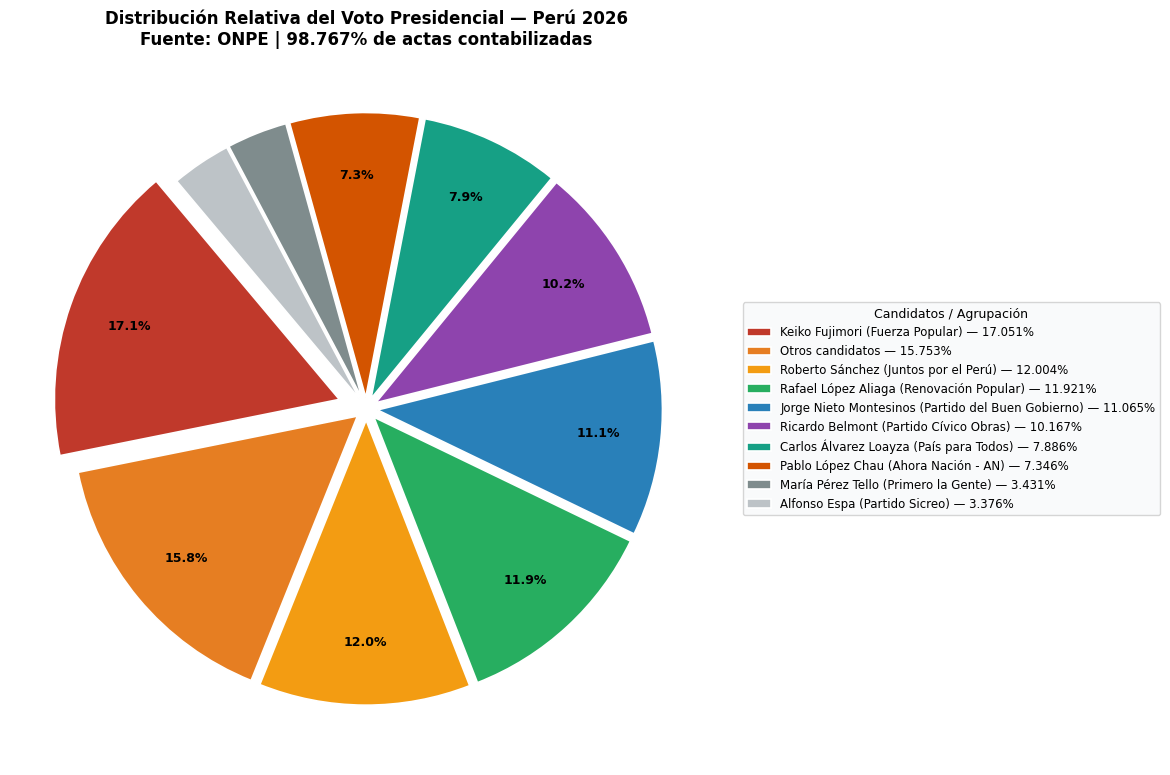

✅ Gráfico guardado: onpe2026_circular.png


In [6]:
# ─────────────────────────────────────────────────────────────
# CELDA 5 — Gráfico circular
# ─────────────────────────────────────────────────────────────
# Paleta de colores para el gráfico circular
PALETTE = [
    "#c0392b", "#e67e22", "#f39c12", "#27ae60",  # Rojo, naranja, amarillo, verde
    "#2980b9", "#8e44ad", "#16a085", "#d35400",  # Azul, morado, verde azulado, naranja oscuro
    "#7f8c8d", "#bdc3c7",                       # Grises
]

# Crear etiquetas para el gráfico (conserva saltos de línea)
etiquetas_pie = [c.replace("\n", "\n") for c in df["candidato"]]

# Crear array de separación (explode) para destacar sectores
explode = [0.04] * len(df)      # Separación base del 4% para todos
explode[0] = 0.10               # Destacar al ganador con 10% de separación

# Crear figura y ejes (tamaño 11x9 pulgadas)
fig, ax = plt.subplots(figsize=(11, 9))

# Crear gráfico circular (pie chart)
wedges, texts, autotexts = ax.pie(
    df["porcentaje_votos"],          # Datos de porcentajes
    labels=None,                     # Sin etiquetas directamente (usaremos leyenda)
    autopct=lambda p: f"{p:.1f}%" if p >= 3.5 else "",  # Mostrar % solo si >= 3.5%
    explode=explode,                 # Separación de sectores
    colors=PALETTE[:len(df)],        # Colores (solo los necesarios)
    startangle=130,                  # Ángulo inicial (130 grados)
    pctdistance=0.78,                # Distancia del porcentaje al centro
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},  # Bordes blancos
)

# Configurar estilo de los textos de porcentaje
for at in autotexts:
    at.set_fontsize(9)               # Tamaño de fuente 9
    at.set_fontweight("bold")        # Negrita

# Leyenda externa (ubicada a la derecha)
ax.legend(
    wedges,                          # Sectores del gráfico
    [f"{e.replace(chr(10), ' ')} — {v:.3f}%"   # Formato: nombre sin salto + porcentaje
     for e, v in zip(etiquetas_pie, df["porcentaje_votos"])],
    title="Candidatos / Agrupación",  # Título de la leyenda
    loc="center left",                # Ubicación: centro izquierda
    bbox_to_anchor=(1.02, 0.5),      # Anclar fuera del área del gráfico
    fontsize=8.5,                    # Tamaño de fuente de la leyenda
    title_fontsize=9,                # Tamaño de fuente del título de leyenda
)

# Título del gráfico
ax.set_title(
    "Distribución Relativa del Voto Presidencial — Perú 2026\n"
    "Fuente: ONPE | 98.767% de actas contabilizadas",
    fontsize=12, fontweight="bold",
)

# Ajustar espaciado automático
plt.tight_layout()

# Guardar el gráfico como archivo PNG (150 dpi)
plt.savefig("onpe2026_circular.png", dpi=150, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

# Mensaje de confirmación de guardado
print("✅ Gráfico guardado: onpe2026_circular.png")

### 3.3 Histograma con Curva KDE — Distribución Estadística del Voto

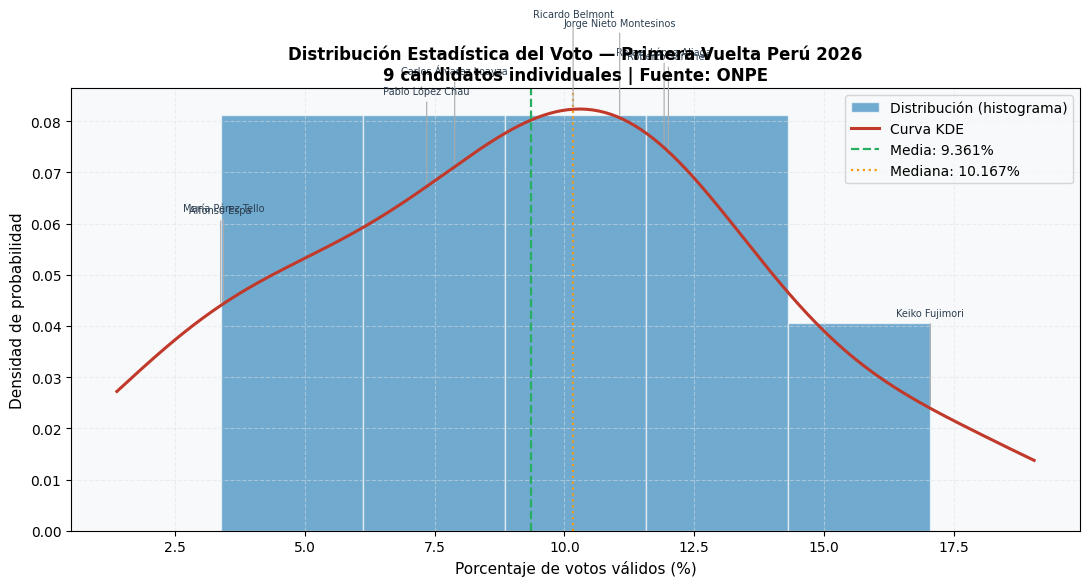

✅ Gráfico guardado: onpe2026_histograma.png


In [7]:
# ─────────────────────────────────────────────────────────────
# CELDA 6 — Histograma + curva KDE
# Solo 9 candidatos individuales (excluye "Otros")
# ─────────────────────────────────────────────────────────────
# Seleccionar votos de los 9 candidatos individuales (excluir "Otros")
votos_ind = votos[:-1]

# Calcular media y mediana de los 9 candidatos
media_ind = np.mean(votos_ind)        # Promedio aritmético
mediana_ind = np.median(votos_ind)    # Valor central

# Crear estimación de densidad por kernel (KDE) con ancho de banda 0.6
kde = gaussian_kde(votos_ind, bw_method=0.6)

# Crear rango de valores para la curva KDE (desde mínimo-2 hasta máximo+2, 300 puntos)
x_range = np.linspace(votos_ind.min() - 2, votos_ind.max() + 2, 300)

# Crear figura y ejes (tamaño 11x6 pulgadas)
fig, ax = plt.subplots(figsize=(11, 6))

# Crear histograma (5 bins, densidad=True para área = 1)
ax.hist(
    votos_ind, bins=5,                 # Datos y número de barras
    color="#2980b9", edgecolor="white", # Azul con borde blanco
    alpha=0.65, density=True,          # Transparencia 65%, normalizado a densidad
    label="Distribución (histograma)",  # Etiqueta para leyenda
)

# Graficar curva de densidad KDE (rojo, grosor 2.2)
ax.plot(x_range, kde(x_range), color="#c0392b", linewidth=2.2, label="Curva KDE")

# Línea vertical para la media (verde, punteada)
ax.axvline(media_ind, color="#27ae60", linestyle="--", linewidth=1.6,
           label=f"Media: {media_ind:.3f}%")

# Línea vertical para la mediana (amarillo, punteada con puntos)
ax.axvline(mediana_ind, color="#f39c12", linestyle=":", linewidth=1.6,
           label=f"Mediana: {mediana_ind:.3f}%")

# Agregar anotaciones (nombre y posición de cada candidato)
for v, c in zip(votos_ind, candidatos[:-1]):  # Recorre votos y nombres (excluye "Otros")
    ax.annotate(
        c.split("\n")[0],                # Solo primera línea del nombre (antes del \n)
        xy=(v, kde(v)[0]),               # Punto a anotar (valor, densidad)
        xytext=(v, kde(v)[0] + 0.018),   # Posición del texto (ligeramente arriba)
        ha="center", fontsize=7, color="#2c3e50",  # Centrado, tamaño 7, gris oscuro
        arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8),  # Flecha sutil
    )

# Etiqueta del eje X
ax.set_xlabel("Porcentaje de votos válidos (%)", fontsize=11)

# Etiqueta del eje Y
ax.set_ylabel("Densidad de probabilidad", fontsize=11)

# Título del gráfico
ax.set_title(
    "Distribución Estadística del Voto — Primera Vuelta Perú 2026\n"
    "9 candidatos individuales | Fuente: ONPE",
    fontsize=12, fontweight="bold",
)

# Mostrar leyenda (tamaño 10)
ax.legend(fontsize=10)

# Ajustar espaciado automático
plt.tight_layout()

# Guardar el gráfico como archivo PNG (150 dpi)
plt.savefig("onpe2026_histograma.png", dpi=150, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

# Mensaje de confirmación de guardado
print("✅ Gráfico guardado: onpe2026_histograma.png")


### 3.4 Diagrama de Caja (Boxplot) — Dispersión y Valores Atípicos

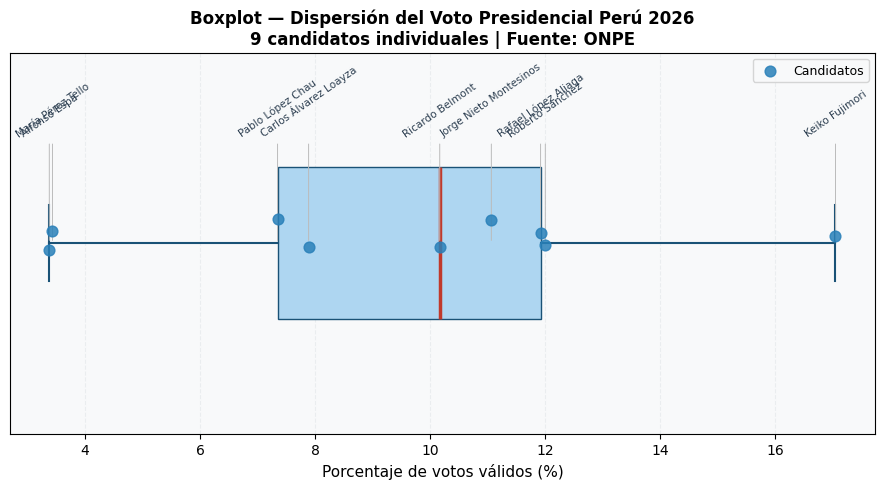

✅ Gráfico guardado: onpe2026_boxplot.png


In [8]:
# ─────────────────────────────────────────────────────────────
# CELDA 7 — Boxplot
# ─────────────────────────────────────────────────────────────
# Seleccionar votos de los 9 candidatos individuales (excluir "Otros")
votos_ind = votos[:-1]

# Crear figura y ejes (tamaño 9x5 pulgadas)
fig, ax = plt.subplots(figsize=(9, 5))

# Crear diagrama de caja y bigotes (boxplot) horizontal
bp = ax.boxplot(
    votos_ind,                         # Datos a graficar
    vert=False,                        # Horizontal (False = caja horizontal)
    patch_artist=True,                 # Rellenar la caja con color
    widths=0.4,                        # Ancho de la caja
    boxprops=dict(facecolor="#aed6f1", color="#1a5276"),  # Caja: azul claro con borde azul oscuro
    medianprops=dict(color="#c0392b", linewidth=2.5),     # Mediana: rojo, grosor 2.5
    whiskerprops=dict(color="#1a5276", linewidth=1.5),    # Bigotes: azul oscuro
    capprops=dict(color="#1a5276", linewidth=1.5),        # Extremos de bigotes: azul oscuro
    flierprops=dict(marker="o", color="#c0392b", markersize=8),  # Valores atípicos: círculo rojo
)

# Puntos individuales superpuestos (con jitter para evitar solapamiento)
np.random.seed(42)                     # Fijar semilla para resultados reproducibles
jitter = np.random.normal(1, 0.04, size=len(votos_ind))  # Distribución normal alrededor de 1
ax.scatter(votos_ind, jitter, color="#2980b9", zorder=5, s=60, alpha=0.85, label="Candidatos")

# Etiquetas de candidatos (nombre + flecha apuntando al punto)
for v, c in zip(votos_ind, candidatos[:-1]):  # Recorre votos y nombres (excluye "Otros")
    ax.annotate(
        c.split("\n")[0],              # Solo primera línea del nombre (antes del \n)
        xy=(v, 1),                     # Punto a anotar (valor, altura 1)
        xytext=(v, 1.28),              # Posición del texto (más arriba)
        ha="center", fontsize=7.5, color="#2c3e50",  # Centrado, tamaño 7.5, gris oscuro
        arrowprops=dict(arrowstyle="-", color="#bbb", lw=0.7),  # Flecha gris clara
        rotation=35,                   # Rotación del texto 35 grados
    )

# Etiqueta del eje X
ax.set_xlabel("Porcentaje de votos válidos (%)", fontsize=11)

# Título del gráfico
ax.set_title(
    "Boxplot — Dispersión del Voto Presidencial Perú 2026\n"
    "9 candidatos individuales | Fuente: ONPE",
    fontsize=12, fontweight="bold",
)

# Eliminar ticks del eje Y (no necesarios en boxplot horizontal)
ax.set_yticks([])

# Mostrar leyenda (tamaño 9)
ax.legend(fontsize=9)

# Ajustar espaciado automático
plt.tight_layout()

# Guardar el gráfico como archivo PNG (150 dpi)
plt.savefig("onpe2026_boxplot.png", dpi=150, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

# Mensaje de confirmación de guardado
print("✅ Gráfico guardado: onpe2026_boxplot.png")


---
## 4. Conclusiones

1. **Fragmentación estructural confirmada:** El coeficiente de variación (~43%) y el NEP >5 evidencian  
   que el sistema de partidos peruano mantiene su alta dispersión histórica.

2. **Ausencia de hegemonía electoral:** Keiko Fujimori lidera con 17.05%, cifra inferior al 20%,  
   reforzando la incapacidad del sistema para generar mayorías en primera vuelta.

3. **Disputa reñida por el segundo cupo:** Roberto Sánchez y Rafael López Aliaga quedaron  
   separados por apenas **0.083 puntos porcentuales** (12.004% vs. 11.921%), la diferencia  
   más estrecha en la historia reciente de segundos puestos presidenciales peruanos.

4. **Continuidad del patrón 2021:** La media de votos del top-7 bajó de 10.95% (2021) a un  
   nivel similar en 2026, con ligera mayor concentración en los tres primeros lugares.

5. **Python + Google Colab como plataforma reproducible:** Este notebook puede ejecutarse  
   íntegramente en Colab sin instalación local, facilitando la replicación ciudadana y académica  
   del análisis electoral oficial.

---
### Referencias
- ONPE (2026). *Resultados Electorales Oficiales — Elecciones Generales 2026*. https://resultadoelectoral.onpe.gob.pe  
- Laakso, M. & Taagepera, R. (1979). "Effective Number of Parties". *Comparative Political Studies*, 12(1), 3–27.  
- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.  
- Tanaka, M. (2005). *Democracia sin partidos: Perú 2000–2005*. IEP.
